# Project Title

## Subtitle

**Author:** Simeona Hein  
**Course:** ENGR 2451  
**Date:** 2026-09-04

# First Project Update

**1. Select Your Dataset**  
My dataset is a collection of Bruker AFM force-volume measurements taken on 6 different surface patterns under ambient humidity. The raw output is a .spm file, normally read with Bruker's Windows-only nanoscope Python package. I reimplemented the force-volume file format in Python (with Claude's help) so it runs on macOS, and verified that it reproduces the adhesion values from the original package. My pipeline extracts variables from the filename and the file header, computes adhesion results from the raw force curves, and writes one row per file to a master .csv.

If I need more observations, I can pull additional data from our low-humidity tests or collect more.

As a backup, I would use stored data from the Surface Topography Challenge to investigate the reliability of optical microscope based techniques across spatial scales. That data is already collected and organized, though I would first need to determine which measurement characteristics (pixel count, magnification, lateral resolution, etc.) are widely reported.

**2. Develop Data Science Questions**  
**Q1. Does humidity increase capillary adhesion, and does surface patterning change that relationship?**
- predictors: % humidity, surface type, probe diameter + probe_ID
- response: average adhesion + distribution    

**Q2. Do RMS roughness parameters (height, slope, and curvature) and/or certain length scales correlate with adhesion?**
- predictors: surface type, z height -> derived PSD -> RMS descriptors integrated over entire length scale or just certain ranges,
- response: average adhesion + distribution    

**Q3. Does probe to wavelength size ratio control adhesion response?**
- predictors: probe diameter, surface type (wavelength composition), humidity, lifetime use of probe_ID (indicates wear + changes on contact area)
- response: average adhesion normalized with probe diameter    

**Q4. Can a same-session Si reference measurement correct for probe to probe variation?**
- predictors: Si surface type adhesion from the same session/probe as other surface type, humidity
- response: average adhesion    

**Q5. Do acquisition settings bias measured adhesion?**
- predictors: applied load, velocity, spring constant
- response: average adhesion    

**Q6. Does local height predict local adhesion within a measurement, and does that coupling strengthen with humidity?**
- within file predictors: local height from FV map (local slope and curvature may also be invovled, but resolution is limited by pixel spacing)
- within file response: adhesion per curve
- across files: per file correlation as response against humidity, surface type, and probe diameter    

**3. Describe Your Proposed Project**  
**What is the problem you want to investigate?**  
I want to investigate how relative humidity affects the relationship between surface topography and capillary adhesion. In humid air, water condenses on surfaces and can form a liquid bridge pulling them together. This is well understood on smooth surfaces, but real surfaces have roughness which limits where and how the bridges form. My surfaces are patterned with different combinations of small, medium, and large wavelengths plus a flat patterned surface and a Si reference wafer, so I can vary the spectral contributions rather than relying on random variation.  

**Why is it interesting or important?**  
Capillary adhesion is typically the dominant adhesive force at small scales in ambient air and it matters anywhere surfaces are in contact (for example MEMS stiction + device failure). The main application I am interested in is in semiconductor wafer manufacturing. These wafers need to be repositioned hundreds of times with nm accuracy while being fabricated. This is done in cleanrooms that have humid environments (dry air can cause excess electrostatic adhesion), so capillary adhesion can lead to errors and yield loss. 

**What does your dataset contain?**  
One row per .spm force-volume file, with each file containing an array of individual force-distance curves. The variables collected fall into 7 groups: probe and humidity information stored in the filenames, experimental conditions from the file header (date/time etc), scan geometry, calibration values (like spring constant and deflection sensitivity), ramp and loading settings (applied load, velocity, etc), adhesion results computed from the force curve array, and topography from z height information. I also have separately measured poser spectral densities (PSDs) for each surface pattern that cover a much wider range of length scales than the AFM height maps and can supplement them.  

**What outcome or response variable will you study?**
The main response variable I will study is mean adhesion force per file in nanonewtons, along with the within file spread of adhesion that should respond to patterning differently than the mean. For the within file questions the response is adhesion per individual curve. All of these variables are computed from the raw force curves within the .spm files.  

**What is your initial data science plan?**

1. Cleaning and grouping by flagging incomplete files, checking that filename and header values agree, and identifying groups in the data such as probe_ID, session, and cantilever stiffness.
2. Exploratory analysis to see how much of the variation sits within files vs between files and which variables the dataset can actually resolve.
3. Testing whether normalizing each measurement against its same-session Si reference reduces probe to probe variation.
4. Computing band limited roughness descriptors from the topography, verifying the topography output vs the original nanoscope package, and cross-checking these descriptors with already measured PSDs.
5. Modeling adhesion against humidty, surface pattern, and probe size using groups that account for the curves within files and files within probes.

# Update 1  

- Accomplishments since the previous update:
  - Selected ~121 .spm files for data extraction to build dataset
  - Reimplemented Bruker's nanoscope package for macOS and Python 3.13
  - Began building master .csv file with all variables of interest
- Approaches you tried that did not work:
  - Bruker's nanoscope package does not run on macOS or Linux (it's a Python wrapper around closed-source Windows DLLs)
  - Reading files from oneDrive stalled indefinitely, files have to be downloaded locally first.
  - 1st version of extraction code ran out of memory on the largest files (~3GB), reading the curves in chunks fixed it.
- What you plan to do next:
  - finish cleaning and grouping the dataset
  - start exploratory analysis
  - verify topography extraction against nanoscope output
- Questions you have about the project:
  - Which research question should I focus on first?
  - Is a per-file summary the only dataset I need, or should individual force curves be stored as rows as well?
- Below is an example of my data type/structure stored in the .spm files. Each pixel of the adhesion map corresponds to 1 force-distance curve. There is also a z height associated with each pixel that can be extracted, but I still need to verify the process against Bruker's nanoscope package.

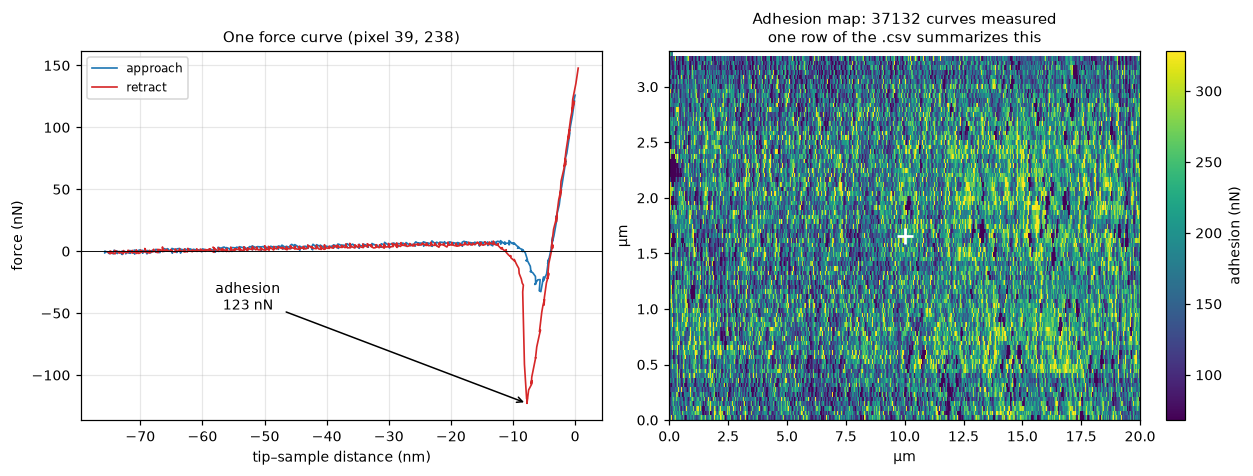